# 8강·9강 학회 발표 정리

**8강:** Clustering, K-Means, DBSCAN, Gaussian Mixture  
**9강:** Perceptron, MLP, Backpropagation, Activation Function

수정본 `Chapter8_9_학회발표_완성본.pptx`의 내용을 실제 슬라이드 순서에 맞춰 정리한 학습 노트이다. 표지·구분 표지·마무리 인사는 제외하고 본문 25개 주제를 담았다. 각 항목의 **PPT 슬라이드 번호는 실제 파일 순서**이며, 슬라이드 하단에 남아 있는 기존 번호와 다를 수 있다.

수식과 표는 편집 가능한 Markdown으로, 교재 그림은 노트북의 첨부 이미지로 포함했다. 코드 실행이나 별도 이미지 폴더가 필요하지 않다. **이해 포인트**는 PPT 내용을 해설한 문단이다.


## 목차

- [슬라이드 2. Clustering: 정답 없이 그룹을 발견한다.](#slide-2)
- [슬라이드 3. Classification과 Clustering의 차이](#slide-3)
- [슬라이드 4. K-Means와 centroid](#slide-4)
- [슬라이드 5. K-Means의 반복: 할당과 중심 갱신](#slide-5)
- [슬라이드 6. Inertia와 초기화의 영향](#slide-6)
- [슬라이드 7. 좋은 k를 고르는 방법: Elbow Method](#slide-7)
- [슬라이드 8. 좋은 k를 고르는 방법: Silhouette](#slide-8)
- [슬라이드 9. 활용 1: Image Segmentation](#slide-9)
- [슬라이드 10. 활용 2: Semi-Supervised Learning](#slide-10)
- [슬라이드 11. K-Means의 한계](#slide-11)
- [슬라이드 12. DBSCAN: 밀집된 이웃을 연결한다](#slide-12)
- [슬라이드 13. DBSCAN의 결과와 한계](#slide-13)
- [슬라이드 14. GMM: Hard Clustering과 Soft Clustering](#slide-14)
- [슬라이드 15. GMM은 데이터의 확률 밀도를 모델링한다](#slide-15)
- [슬라이드 16. GMM을 이용한 Anomaly Detection](#slide-16)
- [슬라이드 17. GMM의 성분 수 선택: AIC와 BIC](#slide-17)
- [슬라이드 18. Bayesian Gaussian Mixture](#slide-18)
- [슬라이드 20. Perceptron: 가중합과 임계값](#slide-20)
- [슬라이드 21. Perceptron의 한계: XOR](#slide-21)
- [슬라이드 22. MLP: 입력층, 은닉층, 출력층](#slide-22)
- [슬라이드 23. Backpropagation을 이용한 학습 과정](#slide-23)
- [슬라이드 24. Chain Rule: 오차의 기울기를 앞쪽으로 전달](#slide-24)
- [슬라이드 25. 비선형 Activation Function이 필요한 이유](#slide-25)
- [슬라이드 26. Sigmoid, tanh, ReLU](#slide-26)
- [슬라이드 27. 문제에 따른 MLP 출력층 구성](#slide-27)

# 8강. 비지도학습과 군집 분석

<a id="slide-2"></a>

## Clustering: 정답 없이 그룹을 발견한다.

**PPT 슬라이드 2** · 8강 · p.246

**군집화는 정답 label이 없는 데이터에서 서로 비슷한 관측값을 묶는 비지도학습이다.**

| 고객 | 나이 | 월 소비액 |
| --- | --- | --- |
| A | 20세 | 20만원 |
| B | 22세 | 25만원 |
| C | 50세 | 150만원 |
| D | 48세 | 140만원 |

**관찰되는 유사성**

A와 B는 나이와 소비액이 비슷하다. C와 D도 서로 가까운 특징을 가진다.

**군집화 결과 예시**

Cluster 0: A, B Cluster 1: C, D

**그룹의 의미는 사람이 해석**

군집 번호만으로 대학생이나 고소득 고객이라는 의미가 자동으로 정해지지는 않는다.

알고리즘은 특징의 유사성으로 그룹을 만들고, 분석자는 그 그룹의 의미를 해석한다.

### 이해 포인트

군집 번호는 그룹을 구별하는 식별자이며 순서나 고객의 의미를 나타내지 않는다. 나이와 소비액의 단위가 다르므로 실제 거리 기반 분석에서는 특징의 스케일도 검토한다.

<a id="slide-3"></a>

## Classification과 Clustering의 차이

**PPT 슬라이드 3** · 8강 · pp.246–250

| 구분 | Classification | Clustering |
| --- | --- | --- |
| 훈련 데이터 | 특징 X와 정답 y | 특징 X만 사용 |
| 학습 목표 | 입력에서 주어진 클래스를 예측 | 비슷한 데이터가 모인 구조 발견 |
| 출력의 의미 | 미리 정의된 클래스 | 사후 해석이 필요한 군집 번호 |

**무엇을 기준으로 비슷하다고 판단하는가?**

K-Means는 주로 Euclidean distance를 이용한다. 2차원에서는 d(x, y) = √[(x₁ − y₁)² + (x₂ − y₂)²]로 거리를 계산한다.

### 이해 포인트

Classification은 주어진 정답을 예측하는 학습이고, Clustering은 정답 없이 구조를 찾는 학습이다. `labels_`라는 이름을 사용해도 군집화 결과는 훈련 때 제공한 정답 라벨이 아니다.

<a id="slide-4"></a>

## K-Means와 centroid

**PPT 슬라이드 4** · 8강 · pp.249–251, 그림 8-3

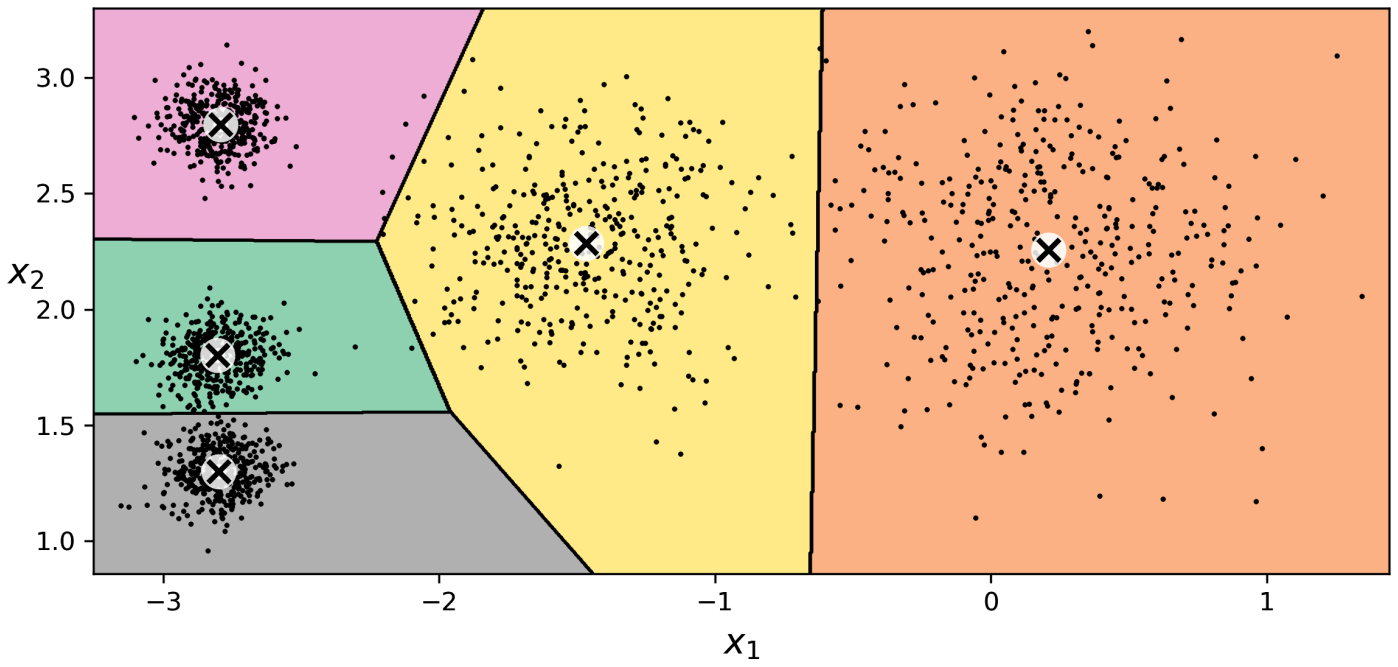

×: centroid / 배경색: 가장 가까운 centroid의 영역

k는 미리 정하는 군집 수

그림은 k=5로 5개의 중심을 만들고, 데이터를 가장 가까운 중심에 배정한다.

Centroid는 군집의 평균 위치

EX) (1,1), (2,1), (3,1)의 centroid는 ((1+2+3)/3, (1+1+1)/3) = (2,1)이다.

중심을 기준으로 공간 분할

중심과의 거리가 짧을수록 그 군집에 속한다. 경계에서는 이웃한 두 중심까지 거리가 같다.

K-Means는 중심을 찾는 과정과 각 데이터의 소속을 정하는 과정을 함께 수행한다.

### 이해 포인트

좌표 (1,1), (2,1), (3,1)은 평균 계산을 보여 주는 설명용 예시이며, 옆 교재 그림에서 추출한 점이 아니다. 각 좌표를 따로 평균하면 (2,1)이 된다. Centroid가 실제 관측값과 일치할 필요는 없다.

<a id="slide-5"></a>

## K-Means의 반복: 할당과 중심 갱신

**PPT 슬라이드 5** · 8강 · pp.251–252, 그림 8-4

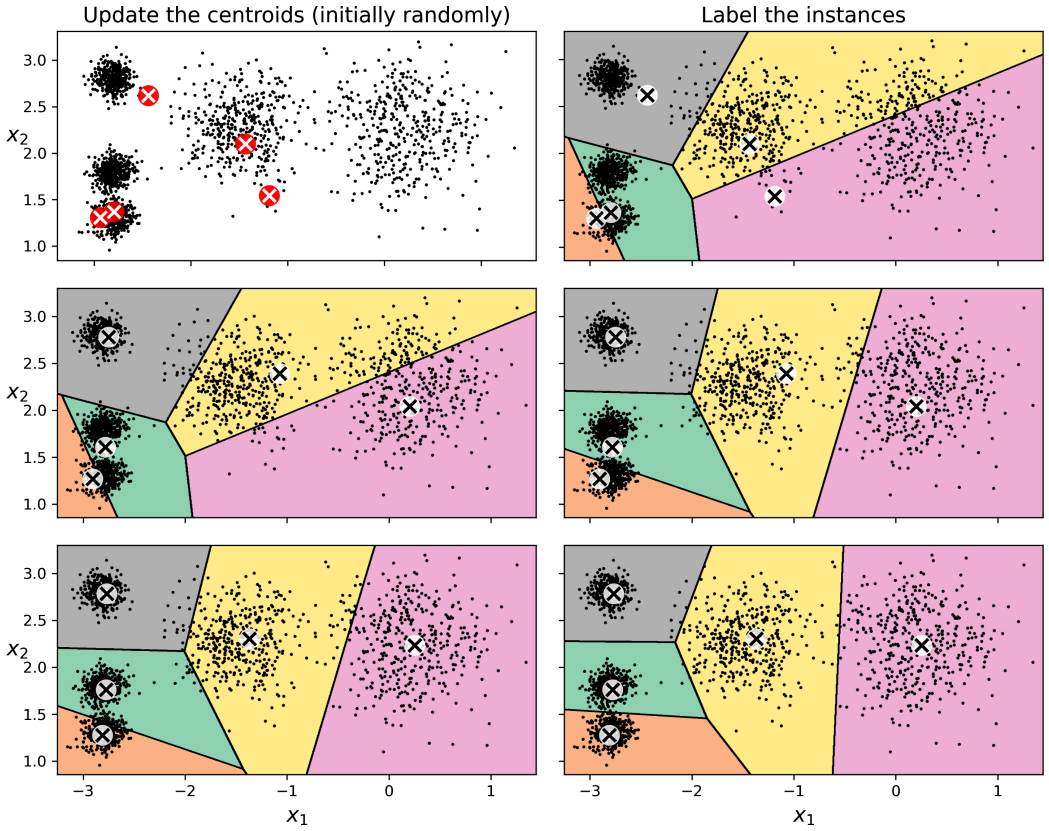

**1. 초기 centroid 선택**

데이터 공간에서 k개의 중심을 초기화한다.

**2. 가장 가까운 centroid에 할당**

$$
c_i=\arg\min_j\lVert x_i-\mu_j\rVert^2
$$

각 데이터 xᵢ의 군집 번호 cᵢ를 결정한다.

**3. 군집별 평균으로 centroid 갱신**

$$
\mu_j=\frac{1}{|C_j|}\sum_{i\in C_j}x_i
$$

현재 군집의 평균 위치로 중심을 옮긴다.

2단계와 3단계를 반복하며, 중심이나 할당이 거의 변하지 않으면 종료한다.

### 이해 포인트

`arg min`은 가장 작은 거리의 값이 아니라 그 값을 만드는 **군집 번호**를 반환한다. 예를 들어 세 중심까지 거리 제곱이 9, 2, 16이면 군집 번호 1에 배정하며, 그 점의 inertia 기여분은 2이다.

<a id="slide-6"></a>

## Inertia와 초기화의 영향

**PPT 슬라이드 6** · 8강 · pp.252–254

$$
J=\sum_i\lVert x_i-\mu_{c_i}\rVert^2
$$

xᵢ: 데이터 / cᵢ: 군집 번호 / μ(cᵢ): 배정된 군집의 centroid

**무엇을 최소화하는가?**

각 데이터와 자신의 centroid 사이 거리의 제곱을 모두 더한다. 같은 데이터와 같은 k에서 값이 작으면 중심 주변에 더 조밀하게 모였다는 뜻이다.

**왜 여러 번 실행하는가?**

반복 계산이 수렴해도 초기 중심에 따라 서로 다른 해가 나올 수 있다. k-means++로 초기 중심을 분산하거나, 여러 실행 중 inertia가 가장 작은 해를 선택한다.

작은 inertia는 유용한 비교 기준이지만, 그 자체로 최적의 군집 수를 알려 주지는 않는다.

### 이해 포인트

Inertia는 군집 내부의 제곱 거리 합이다. 값이 작으면 해당 중심 주변에 더 조밀하게 모였다는 뜻이지만, 다른 군집과의 분리도를 직접 평가하지는 않는다. 같은 데이터·스케일·k에서 비교해야 초기화에 따른 차이를 해석하기 쉽다.

<a id="slide-7"></a>

## 좋은 k를 고르는 방법: Elbow Method

**PPT 슬라이드 7** · 8강 · pp.255–256, 그림 8-7

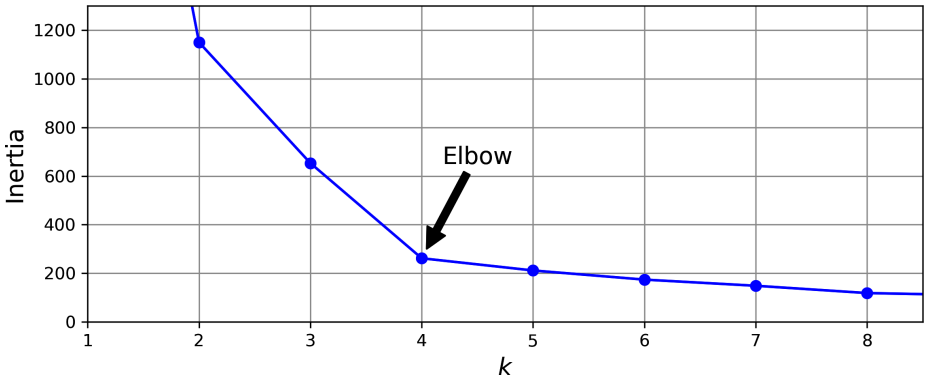

k가 증가하면 inertia는 감소

군집이 많아질수록 각 데이터에 더 가까운 중심을 둘 수 있다. 극단적으로 k=m이면 J=0이다.

감소 폭이 작아지는 지점 탐색

교재 그래프는 k=4 부근에서 꺾인다. 그 이후에는 군집을 추가해도 개선 폭이 작다.

Elbow는 후보를 제시하는 기준

항상 뚜렷한 꺾임이 나타나지는 않는다. 다른 평가 지표와 결과 해석을 함께 확인한다.

가장 작은 inertia를 고르는 대신, 군집을 더 나누는 것이 얼마나 유용한지 판단한다.

### 이해 포인트

군집 수 증가와 inertia 감소 사이의 **트레이드오프**를 살핀다. 최적으로 구한 inertia는 k가 늘면 증가하지 않지만, 실제 실행은 초기화와 지역해의 영향을 받을 수 있다. Elbow는 정답 k를 보장하는 규칙이 아니라 후보 선택을 돕는 휴리스틱이다.

<a id="slide-8"></a>

## 좋은 k를 고르는 방법: Silhouette

**PPT 슬라이드 8** · 8강 · pp.256–258, 그림 8-8

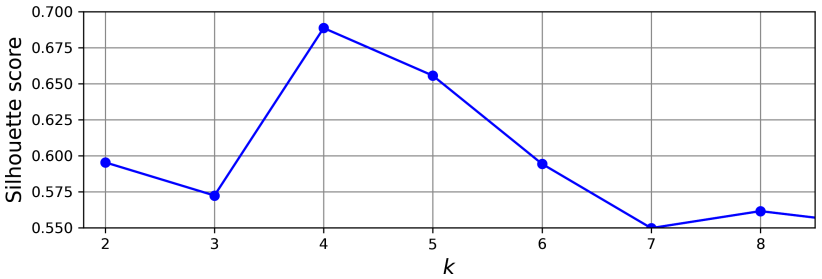

$$
s=\frac{b-a}{\max(a,b)}
$$

a: 같은 군집의 다른 점들까지 평균 거리 b: 다른 군집별 평균 거리 중 가장 작은 값

s가 1에 가까울 때

자기 군집에는 가깝고 다른 군집에는 멀다. 군집 사이의 분리가 잘 이루어진 상태이다.

s가 0 또는 음수일 때

0 부근은 군집 경계에 가까운 경우이다. 음수이면 다른 군집에 더 가까울 수 있다.

점수와 군집별 분포를 함께 확인

교재에서는 k=4와 k=5가 모두 유력하다. 평균 점수 외에 군집 크기와 분리 정도도 본다.

### 이해 포인트

s는 한 데이터의 실루엣 계수이고, 그래프의 Silhouette score는 이를 전체 데이터에 대해 평균한 값이다. b는 다른 군집의 가장 가까운 점까지 거리가 아니라, 다른 군집별 평균 거리 중 최솟값이다.

<a id="slide-9"></a>

## 활용 1: Image Segmentation

**PPT 슬라이드 9** · 8강 · pp.259–261, 그림 8-11

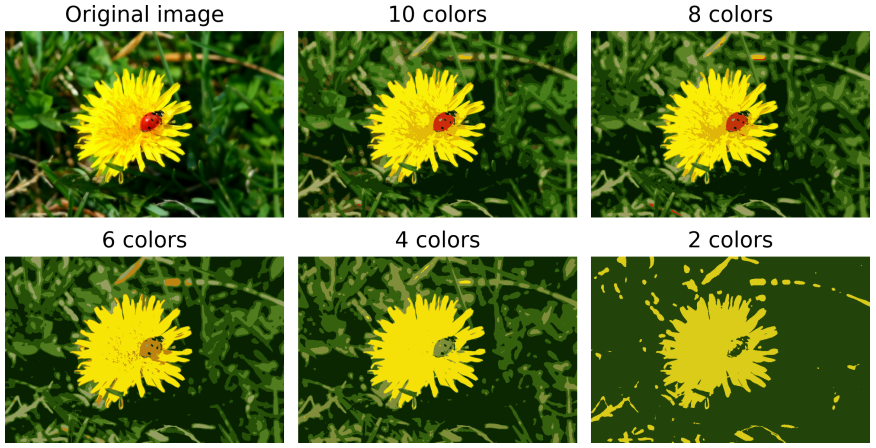

픽셀을 RGB 벡터로 표현

각 픽셀의 (R,G,B)를 하나의 데이터로 보고 색이 비슷한 픽셀끼리 K-Means로 묶는다.

각 픽셀을 대표 색으로 교체

k=8이면 각 픽셀의 색을 자신이 속한 군집의 centroid 색으로 바꾼다.

k가 작아지면 세부 색상이 사라짐

그림에서는 색 수를 줄일수록 꽃과 배경의 색조가 단순해지고 작은 무늬가 사라진다.

### 이해 포인트

픽셀의 위치나 물체 이름 대신 RGB 색상값으로 묶는 예제다. 같은 군집의 픽셀을 centroid 색으로 바꾸면 대표 색의 수가 줄어든다. 이는 객체의 의미를 이해하는 분할과 구분해야 한다.

<a id="slide-10"></a>

## 활용 2: Semi-Supervised Learning

**PPT 슬라이드 10** · 8강 · pp.261–264, 그림 8-12

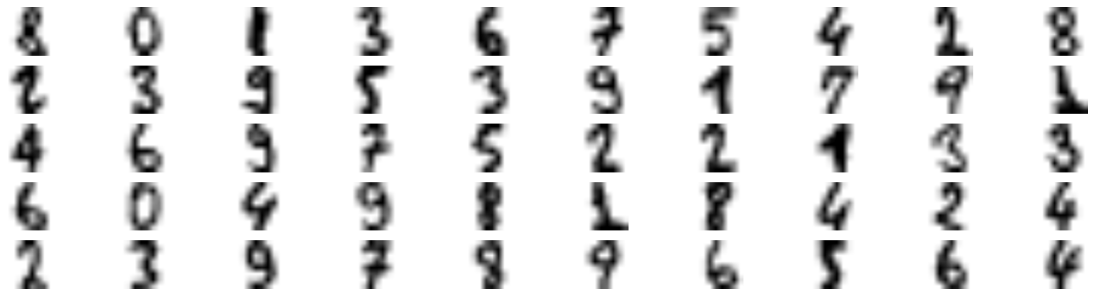

교재의 대표 숫자 이미지 50개: 각 군집에서 centroid에 가장 가까운 표본

1. 군집화와 대표 표본 선택

라벨 없는 데이터를 먼저 묶고, 각 중심에 가까운 표본을 고른다.

2. 대표 표본에 라벨 부여

모든 데이터를 확인하는 대신 대표 표본만 사람이 라벨링한다.

3. 같은 군집으로 라벨 전파

중심에 가까운 표본에 우선 전파해 라벨 오류의 확산을 줄인다.

### 이해 포인트

준지도학습은 라벨이 있는 소량의 데이터와 라벨 없는 데이터를 함께 활용하는 학습이다. 이 예제에서는 대표 숫자에 사람이 라벨을 붙인 뒤 같은 군집으로 전파하고, 확보한 라벨로 분류기를 학습한다. 군집에 다른 숫자가 섞이면 전파 오류가 생길 수 있다.

<a id="slide-11"></a>

## K-Means의 한계

**PPT 슬라이드 11** · 8강 · pp.258–259, 그림 8-10

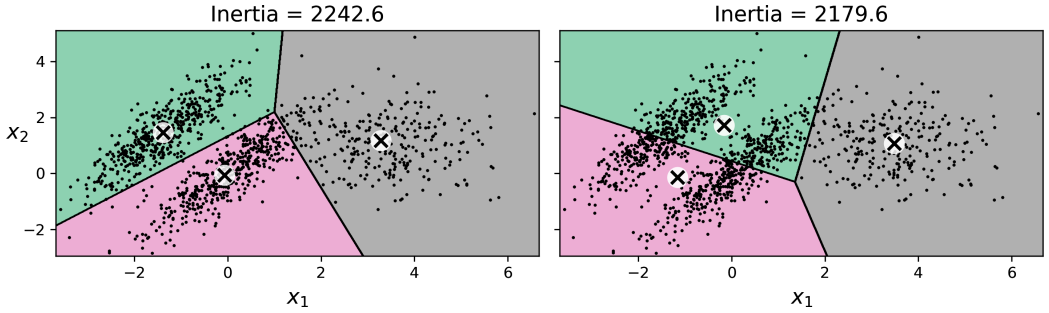

**비슷한 크기의 구형 군집에 적합**

중심까지의 거리만 사용하므로 길쭉하거나 휘어진 군집, 크기·밀도가 다른 군집을 잘못 나눌 수 있다.

**작은 inertia와 좋은 해석은 다를 수 있음**

그림의 오른쪽 해는 inertia가 더 작지만, 타원형 그룹을 자연스럽게 분리하지 못한다.

### 이해 포인트

Inertia가 더 작아도 사람이 기대하는 그룹과 일치하지 않을 수 있다. K-Means의 목적함수는 중심까지 제곱 거리 합을 줄이는 것이므로, 타원형이나 휘어진 군집의 의미상 구조를 그대로 보존한다고 보장할 수 없다.

<a id="slide-12"></a>

## DBSCAN: 밀집된 이웃을 연결한다

**PPT 슬라이드 12** · 8강 · pp.265–267

eps: 이웃을 찾는 반경 min_samples: 핵심점에 필요한 최소 이웃 수 (자신 포함)

| 유형 | 판정 기준 | 군집에서의 역할 |
| --- | --- | --- |
| Core instance | eps 안의 이웃 수가<br>min_samples 이상 | 다른 core와 연결되며<br>군집을 확장한다. |
| Border instance | core는 아니지만<br>core의 eps 이웃에 포함 | 군집에 속하지만<br>스스로 확장을 이어 가지 않는다. |
| Noise / Anomaly | 어떤 core의 eps 이웃에도<br>포함되지 않음 | 군집에서 제외하며<br>교재 구현은 −1로 표시한다. |

### 이해 포인트

`min_samples`는 자기 자신을 포함한 이웃 수다. 핵심점 사이의 연결로 군집을 확장하며, 경계점은 포함하되 경계점을 통해 확장을 이어 가지 않는다. 같은 군집의 모든 점이 서로 eps 이내에 있어야 하는 것은 아니다.

<a id="slide-13"></a>

## DBSCAN의 결과와 한계

**PPT 슬라이드 13** · 8강 · pp.265–267, 그림 8-13

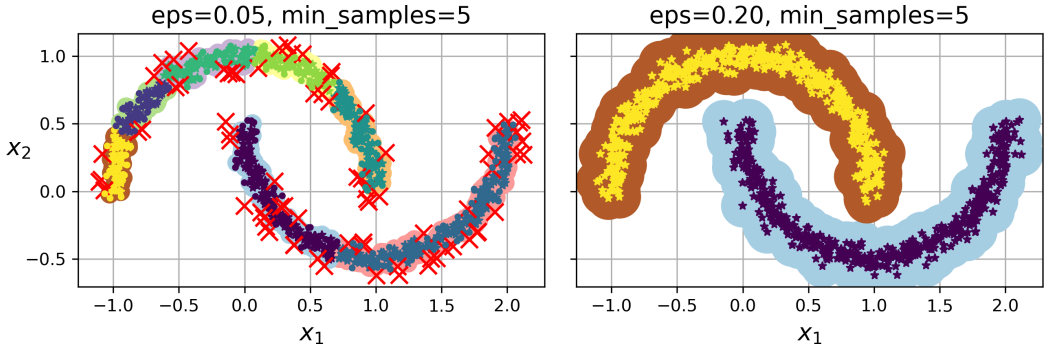

군집 수와 모양을 사전에 정하지 않는다

왼쪽 eps=0.05에서는 군집이 잘게 분리되지만, 오른쪽 eps=0.20에서는 두 곡선 군집을 찾는다.

하나의 밀도 기준으로 전체를 판단한다

eps가 너무 크면 다른 군집이 합쳐질 수 있다. 군집별 밀도가 크게 다르면 하나의 기준이 어렵다.

### 이해 포인트

왼쪽은 작은 eps 때문에 핵심점 연결이 끊겨 여러 군집으로 나뉜다. 색이 다른 영역은 다른 군집, 빨간 ×는 noise이다. 오른쪽은 반경을 넓혀 두 초승달을 각각 연결한 결과다. Noise로 탐지되었다고 실제 오류 데이터이거나 삭제 대상이라는 뜻은 아니다.

<a id="slide-14"></a>

## GMM: Hard Clustering과 Soft Clustering

**PPT 슬라이드 14** · 8강 · pp.269–271

| 구분 | K-Means | Gaussian Mixture |
| --- | --- | --- |
| 배정 방식 | 가장 가까운 중심의 군집에 배정 | 각 성분의 사후 소속 확률 계산 |
| 설명용 예시 | 표본 x는 Cluster 0 | P(C₀&#124;x)=0.7, P(C₁&#124;x)=0.3 |
| 출력 해석 | 하나의 군집 번호 | 군집 소속의 상대적 불확실성 |

**서로 겹치는 군집을 확률로 표현**

경계 부근의 데이터도 반드시 확실하게 나누기보다는 여러 성분에 대한 확률로 표현할 수 있다. 필요하면 가장 높은 확률의 성분을 선택해 하나의 군집 번호로 바꾼다.

### 이해 포인트

Hard clustering은 한 군집으로 배정하고, soft clustering은 여러 군집에 대한 소속 정도를 남긴다. GMM은 사후 소속 확률을 제공하며, 가장 높은 확률을 고르면 hard assignment도 가능하다. 예시의 0.7과 0.3은 설명용 값이다.

<a id="slide-15"></a>

## GMM은 데이터의 확률 밀도를 모델링한다

**PPT 슬라이드 15** · 8강 · pp.269–272, 그림 8-15

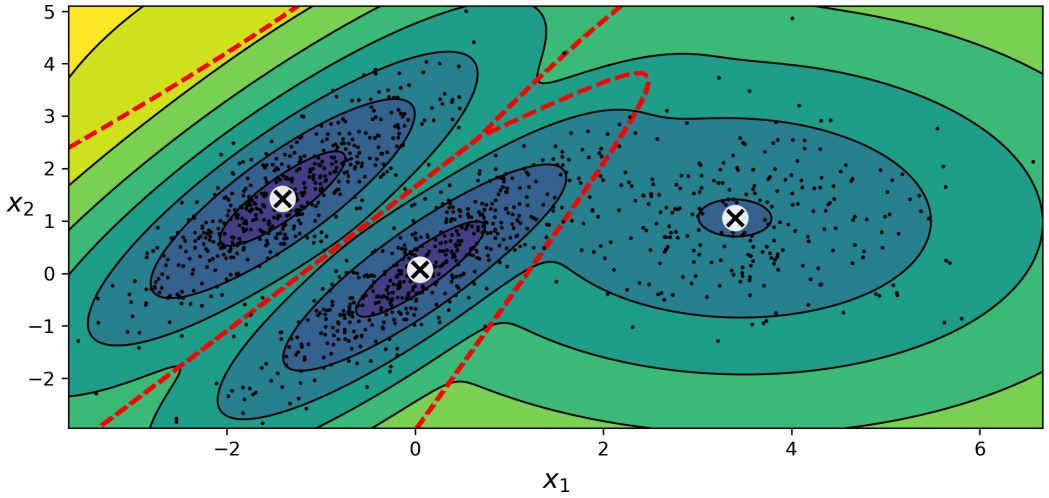

$$
p(x)=\sum_j\pi_j\mathcal{N}(x\mid\mu_j,\Sigma_j)
$$

πⱼ: 혼합 가중치

각 가우시안 성분의 비중이다. πⱼ ≥ 0이고 모든 πⱼ의 합은 1이다.

μⱼ와 Σⱼ: 평균과 공분산

평균은 중심을, 공분산은 퍼짐과 방향을 표현하므로 타원형 군집을 모델링할 수 있다.

p(x): 데이터의 확률 밀도

여러 성분의 밀도를 가중합해 계산한다. 이 값은 낮은 밀도 영역의 탐지에도 쓰인다.

### 이해 포인트

공분산은 분포의 퍼짐과 방향을 표현하므로 타원의 긴 방향에서 중심과 멀어진 점도 해당 성분에 잘 맞을 수 있다. 이것이 단순 중심 거리보다 유연한 점이다. 군집 소속 확률과 전체 밀도 p(x)는 다르며, 연속 분포의 밀도는 영역에 대해 적분해야 확률이 된다.

<a id="slide-16"></a>

## GMM을 이용한 Anomaly Detection

**PPT 슬라이드 16** · 8강 · pp.274–275, 그림 8-17

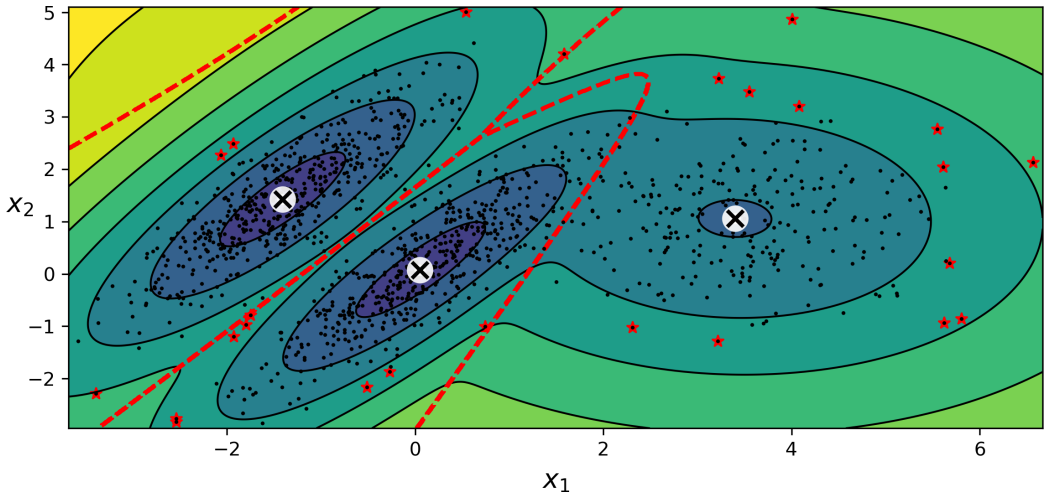

확률 밀도가 낮은 표본을 찾는다

학습한 분포에서 드물게 나타나는 영역의 데이터를 이상치 후보로 판단한다.

임계값 τ로 판정

p(x) < τ이면 이상치로 분류한다. 교재 예시는 밀도 하위 2%를 기준으로 삼는다.

임계값을 조정하면 검출량이 바뀐다

τ를 높이면 더 많은 표본을 검출한다. τ를 낮추면 검출량과 오탐이 줄 수 있다.

그림의 별표는 낮은 밀도 영역에 있어 이상치로 선택된 관측값이다.

### 이해 포인트

하위 2%는 교재의 예시 기준이다. 이상치 비율을 항상 2%로 정하는 것은 아니다. 임계값을 높이면 검출량이 늘고 낮추면 줄어든다. 드문 실제 사건도 이상치일 수 있으므로 탐지 결과의 의미는 별도로 확인해야 한다.

<a id="slide-17"></a>

## GMM의 성분 수 선택: AIC와 BIC

**PPT 슬라이드 17** · 8강 · pp.275–277, 그림 8-19

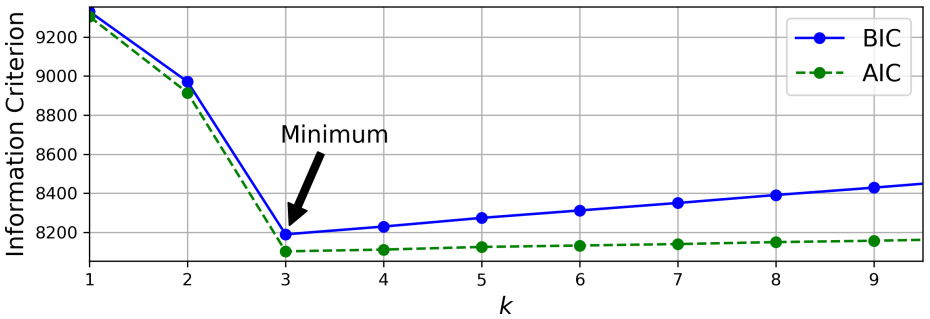

$$
\mathrm{AIC}=2p-2\log L
$$

$$
\mathrm{BIC}=p\log m-2\log L
$$

적합도와 복잡도의 균형

성분을 추가하면 데이터를 더 잘 설명할 수 있지만 추정해야 할 매개변수도 늘어난다.

기호의 의미

p: 학습하는 매개변수 수, m: 표본 수 L: 학습한 모델의 최대 우도

낮은 값의 모델을 선택

교재 그래프에서는 AIC와 BIC가 모두 k=3에서 가장 작다.

데이터를 잘 설명하면서도 불필요하게 복잡하지 않은 모델을 선택한다.

### 이해 포인트

p는 매개변수 수, m은 데이터 수, L은 최대 우도다. AIC와 BIC는 같은 데이터에서 비교하며 낮은 값을 선호한다. BIC는 표본 수가 커질수록 복잡도 벌점이 커져 AIC보다 단순한 모델을 선택하는 경향이 있다.

<a id="slide-18"></a>

## Bayesian Gaussian Mixture

**PPT 슬라이드 18** · 8강 · p.278, 그림 8-20

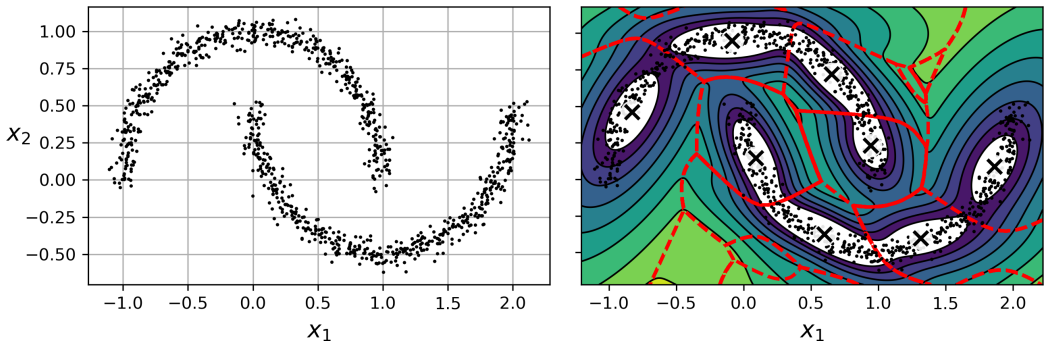

**성분 수에 넉넉한 상한을 두고, 불필요한 성분의 가중치를 작게 만들 수 있다.**

**교재 예시: 10개 성분 허용 가중치 ≈ [0.40, 0.21, 0.39, 0, …, 0]**

유효 성분 수를 데이터에 맞춰 조정

가중치가 거의 0인 성분은 데이터 설명에 거의 기여하지 않는다.

복잡한 모양에는 여전히 한계

두 moon을 여러 타원형 성분으로 쪼갠다. 성분 수가 의미상 군집 수와 같지는 않다.

Bayesian GMM도 가우시안 성분이라는 가정과 설정한 상한·사전분포의 영향을 받는다.

### 이해 포인트

표시된 0은 반올림된 값으로, 실제로는 아주 작은 양수일 수 있다. 유효 성분 수는 상한과 사전분포 등의 영향을 받는다. 밀도 표현에 필요한 성분 수와 사람이 기대하는 군집 수가 항상 같지는 않다.

# 9강. 인공신경망과 MLP

<a id="slide-20"></a>

## Perceptron: 가중합과 임계값

**PPT 슬라이드 20** · 9강 · pp.290–291, 그림 9-4

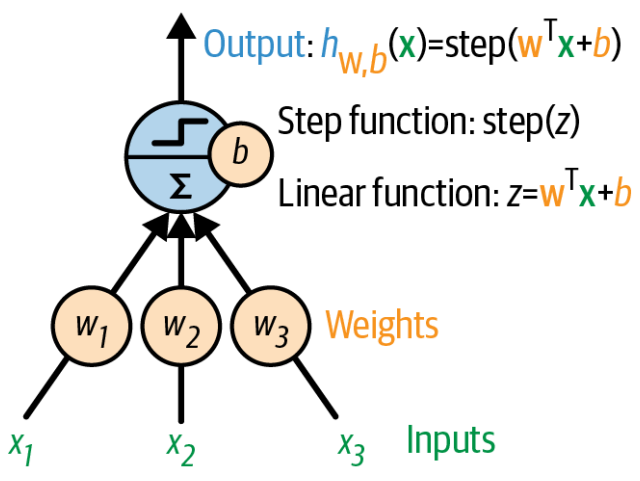

가중합에 bias를 더한다

$$
z=w^\top x+b=\sum_iw_ix_i+b
$$

w는 입력의 영향, b는 판단 기준의 위치를 조절한다.

Step function으로 결과 결정

$$
\hat y=\begin{cases}1 & z\geq 0\\0 & z<0\end{cases}
$$

계산값이 임계값을 넘는지로 출력을 정한다.

단순한 신경망의 기본 계산 단위

TLU는 입력, 가중치, bias, step function으로 구성된다. 틀린 예측을 줄이도록 가중치를 학습한다.

선형 점수 wᵀx+b에 임계값을 적용하므로 한 출력 뉴런의 결정 경계는 선형이다.

### 이해 포인트

가중합 z는 최종 클래스가 아니라 판단 점수다. Step function이 이 점수의 부호에 따라 0 또는 1을 출력한다. 출력 1은 확률 100%라는 뜻이 아니다. 두 입력에서 결정 경계는 직선이며, 가중치는 방향, bias는 위치에 영향을 준다.

<a id="slide-21"></a>

## Perceptron의 한계: XOR

**PPT 슬라이드 21** · 9강 · pp.294–295, 그림 9-6

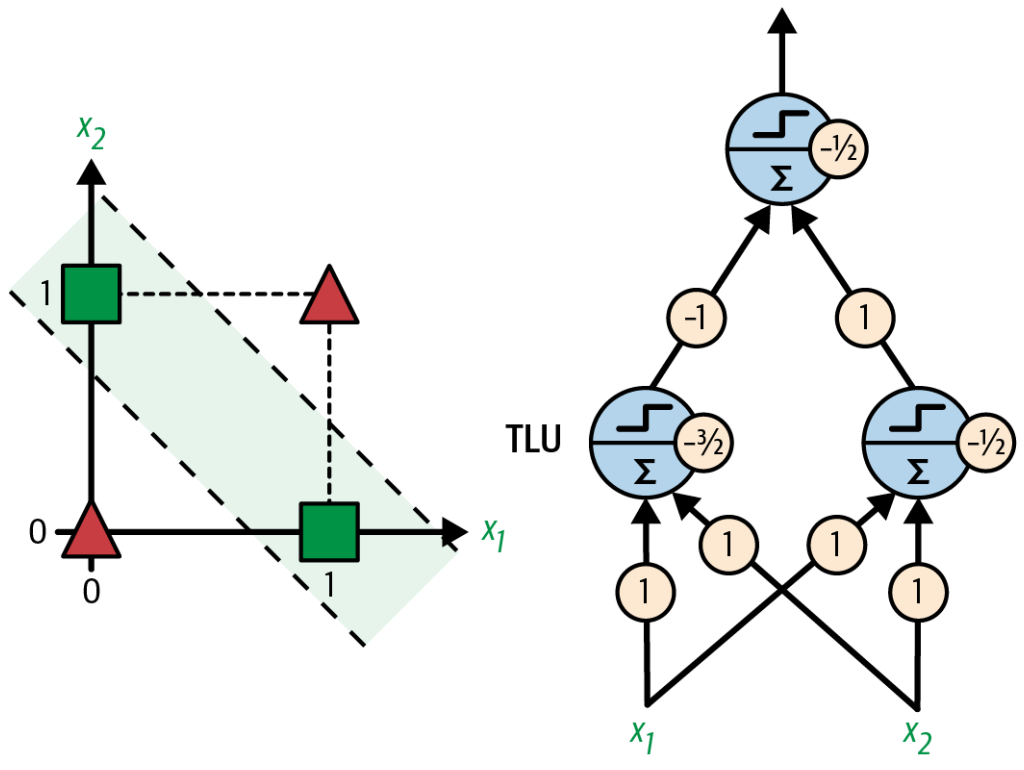

XOR의 출력

(0,0), (1,1)은 0 (0,1), (1,0)은 1

하나의 직선으로는 분리 불가

같은 클래스가 대각선 양쪽에 위치하므로 단일 선형 경계로 네 점을 나눌 수 없다.

여러 뉴런의 계산을 조합

오른쪽처럼 중간 계산층을 두면 여러 경계를 조합해 XOR를 표현할 수 있다.

여러 층과 비선형 계산을 결합한 MLP는 단일 Perceptron의 표현 한계를 넓힌다.

### 이해 포인트

XOR는 두 입력이 다를 때 1이고 같을 때 0이다. 같은 클래스가 대각선으로 놓이므로 하나의 직선으로는 분리할 수 없다. 은닉층의 여러 비선형 계산을 조합하면 두 경계 사이 영역을 표현할 수 있다.

<a id="slide-22"></a>

## MLP: 입력층, 은닉층, 출력층

**PPT 슬라이드 22** · 9강 · pp.294–295, 그림 9-7

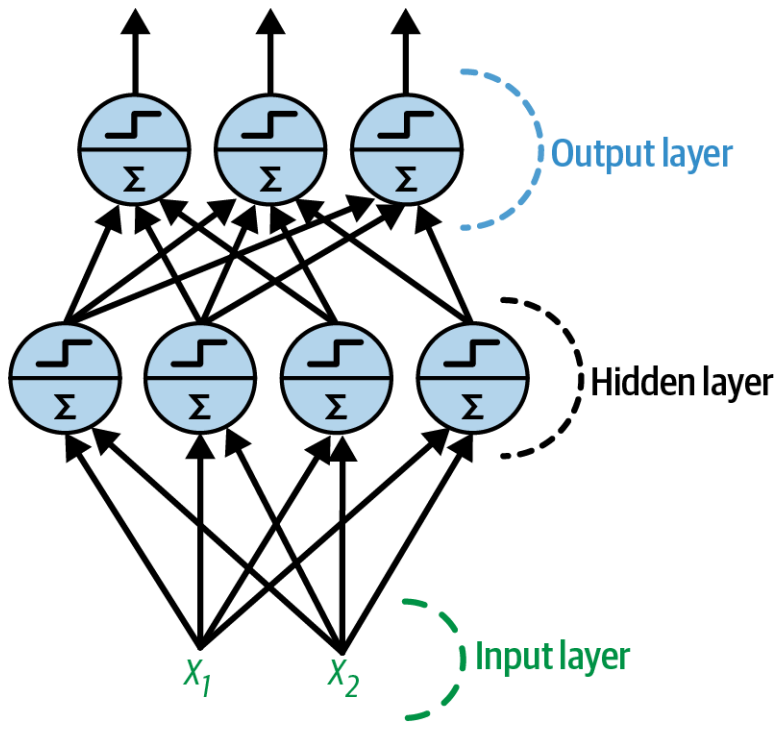

**Input layer**

원래 특징 x를 네트워크로 전달한다.

**Hidden layer(s)**

이전 층의 출력을 가중합하고 비선형 활성화를 적용해 다음 층에서 사용할 표현을 만든다.

**Output layer**

최종 표현을 회귀값이나 클래스 예측으로 바꾼다. 문제에 따라 뉴런 수와 활성화 함수를 정한다.

Feedforward network에서는 예측을 계산할 때 신호가 입력에서 출력 방향으로 흐른다.

### 이해 포인트

그림은 입력 2개, 은닉 뉴런 4개, 출력 뉴런 3개의 구조다. 은닉 뉴런들은 같은 입력을 받아도 가중치가 달라 서로 다른 표현을 만들 수 있다. Feedforward는 예측값 계산 방향을 말하며, 학습 시 기울기를 반대로 계산하는 역전파와 모순되지 않는다.

<a id="slide-23"></a>

## Backpropagation을 이용한 학습 과정

**PPT 슬라이드 23** · 9강 · pp.296–298

**1. Forward pass: 현재 매개변수로 예측**

입력에서 출력까지 각 층의 값을 계산한다. 미분에 필요한 중간 계산값도 함께 저장한다.

**2. Loss: 예측과 정답의 차이를 하나의 값으로 측정**

ŷ와 y를 손실 함수에 넣는다. 회귀에는 제곱오차, 분류에는 교차엔트로피 등을 사용한다.

**3. Backward pass: 각 매개변수의 gradient 계산**

출력층에서 앞쪽 층으로 chain rule을 적용해 ∂L/∂w와 ∂L/∂b를 효율적으로 계산한다.

**4. Gradient descent: 손실이 줄어드는 방향으로 갱신**

$$
w_{\mathrm{new}}=w-\eta\frac{\partial L}{\partial w},\qquad b_{\mathrm{new}}=b-\eta\frac{\partial L}{\partial b}\quad (\eta:\ \text{learning rate})
$$

역전파는 기울기를 계산하고, 최적화 단계는 그 기울기를 이용해 매개변수를 수정한다.

### 이해 포인트

역전파는 각 매개변수에 대한 손실의 기울기를 계산하고, 경사하강법은 그 기울기로 실제 값을 갱신한다. 기울기의 반대 방향이 현재 위치에서 손실을 줄이는 방향이지만, 너무 큰 학습률로 이동하면 손실이 오히려 커질 수 있다.

<a id="slide-24"></a>

## Chain Rule: 오차의 기울기를 앞쪽으로 전달

**PPT 슬라이드 24** · 9강 · pp.297–298

$$
z=wx+b,\qquad a=\phi(z),\qquad L=\ell(a,y)
$$

$$
\frac{\partial L}{\partial w}=\frac{\partial L}{\partial a}\frac{\partial a}{\partial z}\frac{\partial z}{\partial w}
$$

| 미분 항 | 무엇을 나타내는가? |
| --- | --- |
| ∂L/∂a | 뉴런 출력 a가 조금 변할 때 손실이 얼마나 변하는가 |
| ∂a/∂z = φ′(z) | 가중합 z의 변화가 활성화 출력에 얼마나 전달되는가 |
| ∂z/∂w = x | 가중치 w의 변화가 가중합 z에 얼마나 전달되는가 |

여러 층에서도 같은 원리로 계산한다. 뒤에서 받은 기울기에 현재 연산의 미분을 곱한다.

### 이해 포인트

w의 변화가 z, a를 거쳐 L에 영향을 주므로 경로를 따라 미분을 곱한다. 여러 층에서도 뒤에서 받은 기울기에 현재 연산의 국소 미분을 곱한다. 하나의 값이 여러 경로로 손실에 영향을 주면 각 경로에서 온 기울기를 더한다.

<a id="slide-25"></a>

## 비선형 Activation Function이 필요한 이유

**PPT 슬라이드 25** · 9강 · pp.298–299

**선형 변환만 여러 층 쌓으면 전체 계산도 하나의 선형 변환으로 합쳐진다.**

$$
g(x)=5x-1,\qquad f(x)=2x+3
$$

$$
f(g(x))=2(5x-1)+3=10x+1
$$

**깊이만 늘려서는 표현력이 충분히 늘지 않는다**

비선형 함수 φ를 적용해야 직선 하나로 나누기 어려운 패턴을 여러 층의 조합으로 표현할 수 있다.

**경사 기반 학습이 가능한 활성화를 사용한다**

Step function은 대부분의 구간에서 기울기가 0이다. Sigmoid, tanh, ReLU처럼 유용한 기울기를 전달하는 함수를 사용한다.

### 이해 포인트

Bias를 포함한 변환은 엄밀히 아핀 변환이다. 이러한 변환만 쌓으면 하나로 합칠 수 있으므로 비선형 활성화가 필요하다. Step function도 비선형이지만 거의 모든 곳에서 미분이 0이어서 일반적인 경사 기반 학습에 적합하지 않다.

<a id="slide-26"></a>

## Sigmoid, tanh, ReLU

**PPT 슬라이드 26** · 9강 · pp.298–299, 그림 9-8

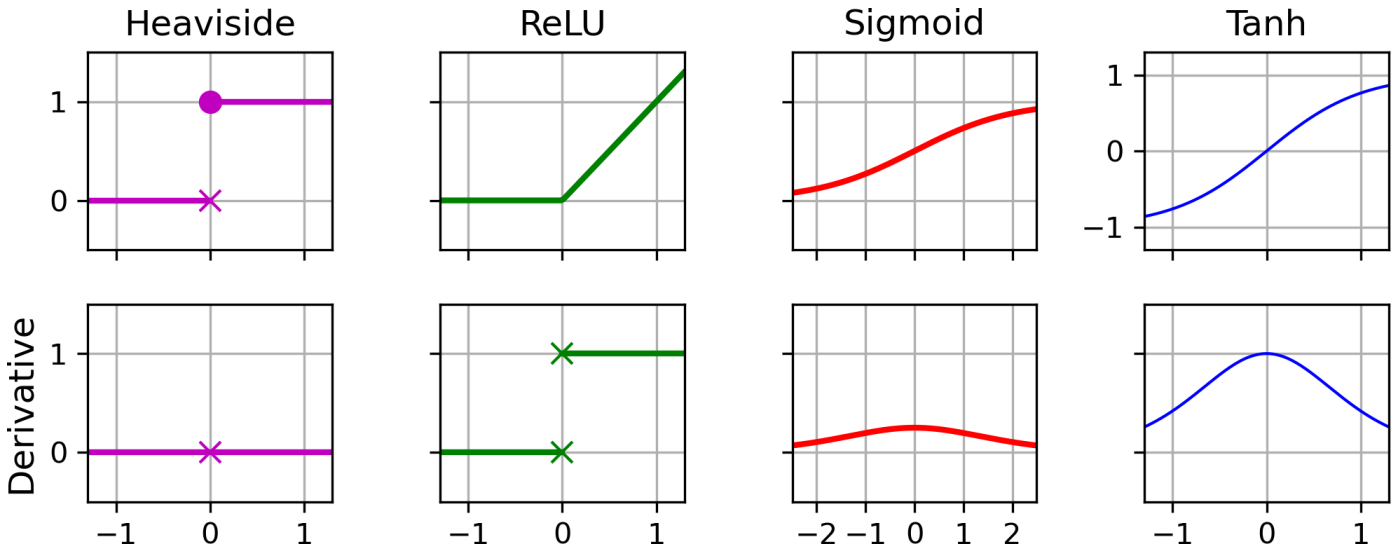

| 함수 | 정의와 출력 범위 | 핵심 특징 |
| --- | --- | --- |
| Sigmoid | σ(z)=1/(1+e⁻ᶻ), 0~1 | 양 끝에서 기울기가 작아진다.<br>이진 분류 출력에도 사용한다. |
| tanh | tanh(z), −1~1 | 0을 중심으로 출력하지만<br>양 끝에서는 역시 포화된다. |
| ReLU | max(0,z), 0 이상 | 양수 영역의 미분이 1이다.<br>은닉층에서 널리 사용하는 선택이다. |

### 이해 포인트

교재 그림은 위쪽이 함수값, 아래쪽이 미분이다. Sigmoid와 tanh는 양 끝에서 포화되어 기울기가 작아진다. ReLU는 양수 구간에서 미분이 1이고 음수 구간에서는 0이다. 0에서는 수학적으로 미분이 정의되지 않는다.

<a id="slide-27"></a>

## 문제에 따른 MLP 출력층 구성

**PPT 슬라이드 27** · 9강 · pp.303–304, 표 9-1·9-2 / pp.308–310

| 문제 | 출력 뉴런 수 | 활성화 | 출력 해석 |
| --- | --- | --- | --- |
| Regression | 타깃 수 | 보통 없음 | 제약 없는 연속값 |
| Binary classification | 1개 | Sigmoid | 양성 클래스일 확률 |
| Multilabel | 라벨당 1개 | Sigmoid | 여러 라벨이 동시에 참일 수 있음 |
| Multiclass | 클래스당 1개 | Softmax | 상호 배타적 클래스, 확률 합=1 |

### 이해 포인트

Multilabel은 여러 라벨이 동시에 참일 수 있어 각각 Sigmoid를 사용하며 확률 합이 1일 필요가 없다. Multiclass는 하나의 클래스가 정답인 경우이므로 Softmax로 확률 합을 1로 만든다. 회귀 출력은 보통 활성화 없이 연속값을 예측한다.